# 10 · Memory, Part 3 — The Evaluation Harness

Notebooks 08–09 built the **read** side of memory: a store, retrievers, and a grounded/abstaining answerer. This notebook adds the **write** side and finally answers the question the whole thread has been circling:

> Does external memory actually beat the context window?

Three pieces, each measured rather than asserted:

1. **Write policies** — a `MemoryWriter` with *write-all*, *dedup*, and *capacity* (forgetting). *What* you store and *when* is a design choice with consequences you can put a number on.
2. **The dedup trap** — semantic dedup *merges away* the confusable clusters from Notebook 08, because the distinguishing ID barely moves the embedding. Consolidation needs a lexical guard.
3. **The money plot** — a multi-turn session benchmark: facts stated early, queried late. A fixed context window forgets old facts on a cliff; an external store does not. This is the empirical payoff for everything in Notebook 05's context-limit discussion.

Reusable code: `llmlab/memory/writer.py`, `llmlab/evals/sessions.py`; tests: `tests/test_memory_harness.py`.

In [ ]:
import sys
from pathlib import Path

LLM_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(LLM_DIR) not in sys.path:
    sys.path.insert(0, str(LLM_DIR))

import json
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["HF_HUB_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
transformers.utils.logging.disable_progress_bar()
import huggingface_hub
huggingface_hub.logging.set_verbosity_error()

from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from llmlab import config
from llmlab.models.local_model import LocalModel, SamplingConfig
from llmlab.memory.store import MemoryStore
from llmlab.memory.writer import MemoryWriter
from llmlab.retrieval.embeddings import Embedder
from llmlab.retrieval.retrievers import DenseRetriever
from llmlab.agent.rag import static_rag_answer
from llmlab.evals.memory_qa import contains_answer
from llmlab.evals import sessions as S
from llmlab.evals.sessions import make_sessions, answer_from_window

config.configure_caches()
config.ensure_dirs()
config.seed_everything(0)

embedder = Embedder()
model = LocalModel("Qwen/Qwen2.5-0.5B-Instruct", dtype="float32", attn_implementation="sdpa")

print(f"device={model.device} | fact bank={len(S.FACT_BANK)} | filler lines={len(S.FILLER)}")

device=mps | fact bank=16 | filler lines=10


## 1. The write side — what to store, and when

Retrieval is useless if the right fact was never written. `MemoryWriter` wraps the store with three policies:

- **write-all** — append every utterance verbatim. Simple, but the store fills with chit-chat and exact repeats.
- **dedup** — skip a new fact whose cosine to an existing memory is ≥ a threshold. Shrinks the store; ideal for true repeats.
- **capacity** — a bounded store that evicts the oldest memory (the simplest *forgetting* policy).

The writer keeps its own embedding matrix, so dedup is a single matrix–vector product with no re-embedding. Below, the same short stream — four distinct facts, one exact repeat, one line of chit-chat — under each policy.

In [ ]:
def run_policy(items, **kw):
    store = MemoryStore()
    writer = MemoryWriter(store, embedder, **kw)
    results = [writer.write(t) for t in items]
    return store, results

facts = [f.statement for f in S.FACT_BANK[:4]]
stream = facts + [facts[0], "By the way, the weather has been lovely this week."]
#                  ^ exact repeat (idx 4)      ^ chit-chat, no durable fact (idx 5)

store_all, _ = run_policy(stream)
store_dd, res_dd = run_policy(stream, dedup_threshold=0.9)
store_cap, res_cap = run_policy(facts, capacity=3)

dropped = [i for i, r in enumerate(res_dd) if not r.stored]
evicted = [r.evicted for r in res_cap if r.evicted]

print(f"stream length                 : {len(stream)}")
print(f"write-all   -> store size      : {len(store_all)}   (keeps the repeat AND the chit-chat)")
print(f"dedup(0.90) -> store size      : {len(store_dd)}   (dropped stream index {dropped} — the exact repeat)")
print(f"capacity=3 over {len(facts)} facts -> size {len(store_cap)}   (evicted oldest: {evicted})")

stream length                 : 6
write-all   -> store size      : 6   (keeps the repeat AND the chit-chat)
dedup(0.90) -> store size      : 5   (dropped stream index [4] — the exact repeat)
capacity=3 over 4 facts -> size 3   (evicted oldest: ['m001'])


## 2. The dedup trap — semantic similarity can't see the ID

Dedup looks safe until it meets a **confusable cluster** (Notebook 08): five incidents with *identical* text except an opaque code. To a dense embedder they are near-duplicates — but they are five *different* facts, and the code is the only thing that distinguishes them.

We sweep the dedup threshold and measure two things: how many incidents survive (`stored`) and how many are still answerable by their ID (`recall@1`, i.e. the top hit for "Which incident was INC-XXXX?" actually contains that code). Watch what a "reasonable" near-duplicate threshold of 0.90 does.

pairwise cosine among the 5 incidents: min=0.878  mean=0.905  max=0.936  (they look like near-duplicates)


 threshold  stored  recall@1
       NaN       5         5
      0.97       5         5
      0.95       5         5
      0.94       5         5
      0.93       4         4
      0.92       3         3
      0.91       3         3
      0.90       2         2
      0.88       1         1
      0.86       1         1


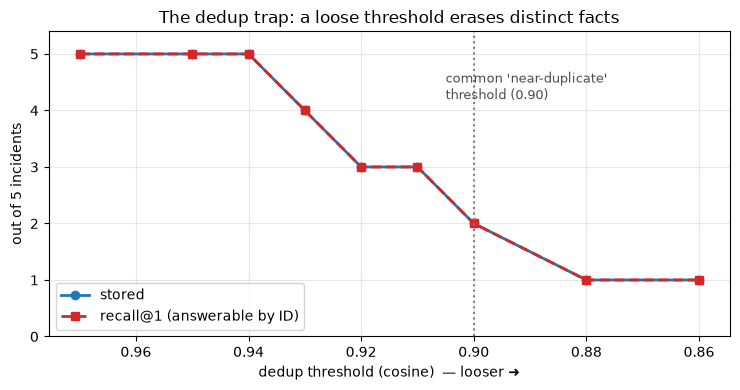

In [ ]:
CODES = ["INC-2055", "INC-3071", "INC-4188", "INC-5219", "INC-6634"]
INCIDENTS = [f"Incident {c} was caused by a memory leak in the websocket handler." for c in CODES]

vecs = embedder.encode(INCIDENTS)
off = (vecs @ vecs.T)[~np.eye(len(CODES), dtype=bool)]
print(f"pairwise cosine among the {len(CODES)} incidents: "
      f"min={off.min():.3f}  mean={off.mean():.3f}  max={off.max():.3f}  (they look like near-duplicates)")

thresholds = [None, 0.97, 0.95, 0.94, 0.93, 0.92, 0.91, 0.90, 0.88, 0.86]
rows = []
for thr in thresholds:
    store = MemoryStore()
    writer = MemoryWriter(store, embedder, dedup_threshold=thr)
    for text in INCIDENTS:
        writer.write(text)
    retr = DenseRetriever(store, embedder)
    recall = sum(bool(h := retr.search(f"Which incident was {c}?", 1)) and c in h[0].text for c in CODES)
    rows.append({"threshold": thr, "stored": len(store), "recall@1": recall})

dedup_df = pd.DataFrame(rows)
dedup_df["threshold"] = dedup_df["threshold"].map(lambda t: "none" if t is None else t)
print(dedup_df.to_string(index=False))

xs = [r["threshold"] for r in rows if r["threshold"] is not None]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(xs, [r["stored"] for r in rows if r["threshold"]], "o-", color="#1f77b4", lw=2, label="stored")
ax.plot(xs, [r["recall@1"] for r in rows if r["threshold"]], "s--", color="#d62728", lw=2, label="recall@1 (answerable by ID)")
ax.axvline(0.90, color="0.5", ls=":")
ax.annotate("common 'near-duplicate'\nthreshold (0.90)", xy=(0.90, 4.2), xytext=(0.905, 4.2),
            fontsize=9, color="0.3")
ax.invert_xaxis()  # looser thresholds (more merging) to the right
ax.set_xlabel("dedup threshold (cosine)  — looser ➜")
ax.set_ylabel(f"out of {len(CODES)} incidents")
ax.set_title("The dedup trap: a loose threshold erases distinct facts")
ax.set_ylim(0, 5.4)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The cliff is brutal. The incidents sit at cosine ≈ 0.88–0.94, so a 0.90 "near-duplicate" threshold collapses five facts into two and makes three of them **permanently unanswerable** — they were never stored. `stored` and `recall@1` move together because every merged-away record is a lost answer.

This is Notebook 08's lesson, now on the write side: the distinguishing token (the ID) barely moves a dense embedding, so *semantic* dedup is exactly the wrong tool for confusable facts. Safe consolidation needs a **lexical guard** — require a candidate and its match to share their identifiers (a BM25 / exact check) before merging, or only dedup within a topic. **Dedup repeats, not IDs.**

## 3. The real test — does memory beat the context window?

Everything so far is single-turn. The reason we build memory at all is **long horizons**: a fact mentioned an hour ago should still be answerable. Notebook 05 showed the context window is finite and quadratic; here we measure the consequence and the cure.

A **session** states facts (each with a distinctive, verbatim answer) interleaved with chit-chat, then asks about every fact at the end. A fact's **distance** is how many turns back it was stated. We compare three ways to answer:

- **no-memory** — answer from only the last `WINDOW` turns (a controlled stand-in for a fixed context window). Facts older than the window are simply gone.
- **memory** — every fact was written to an *unbounded* store; retrieve top-k and answer.
- **memory (cap=k)** — the same, but the store is capacity-bounded, so the oldest facts were evicted (forgetting).

If memory works, its recall should be **flat across distance** while no-memory falls off a cliff at the window boundary. Here is one session.

In [ ]:
SESSIONS = make_sessions(n_sessions=5, n_facts=8, spacing=2, seed=0)
WINDOW = 12       # no-memory context window, in turns
CAPACITY = 6      # memory capacity, in facts

demo = SESSIONS[0]
print(f"one session = {len(demo.turns)} turns ({len(demo.facts)} facts interleaved with chit-chat)\n")
for i, t in enumerate(demo.turns[:7]):
    print(f"  turn {i:>2} | {'FACT' if t.is_fact else '    '} | {t.text}")
print("   ...\n\nthen, at the end, we ask about every fact (distance = turns since it was stated):")
for fact, dist in demo.recall_items()[:4]:
    print(f"  d={dist:>2}  Q: {fact.question:<42} -> {fact.answer}")

one session = 24 turns (8 facts interleaved with chit-chat)

  turn  0 | FACT | The database shard is named shard-delta.
  turn  1 |      | Let's keep the momentum going.
  turn  2 |      | I might repaint the fence this weekend.
  turn  3 | FACT | My badge number is BR-3162.
  turn  4 |      | The cafeteria added a new sandwich option.
  turn  5 |      | Remind me to stretch now and then.
  turn  6 | FACT | The office wifi password is rocket-42.
   ...

then, at the end, we ask about every fact (distance = turns since it was stated):
  d=24  Q: What is the database shard named?          -> shard-delta
  d=21  Q: What is my badge number?                   -> BR-3162
  d=18  Q: What is the office wifi password?          -> rocket-42
  d=15  Q: What is my flight number to Tokyo?         -> DL482


## 4. Recall vs distance — the money plot

The hypothesis, stated sharply:

- **no-memory** — recall ≈ 1.0 inside the window, ≈ 0 outside. A hard cliff at the budget: the model can't answer what it can't see.
- **memory (unbounded)** — recall ≈ 1.0 *everywhere*; once a fact is in the store, distance is irrelevant.
- **memory (cap=k)** — flat until the oldest facts are evicted, then it drops. Forgetting is a *tunable, softer* cliff.

For each fact we ask its question under all three conditions and score whether the gold token appears in the answer.

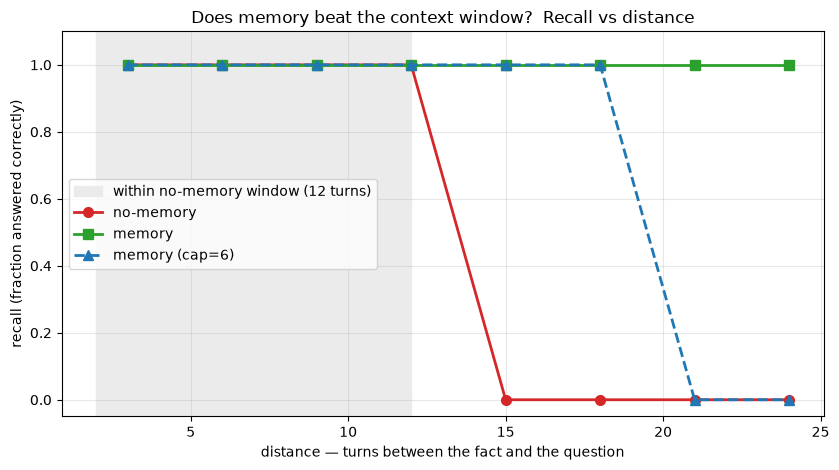

                 3    6    9    12   15   18   21   24
no-memory       1.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0
memory          1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
memory (cap=6)  1.0  1.0  1.0  1.0  1.0  1.0  0.0  0.0


In [ ]:
SAMP = SamplingConfig(max_new_tokens=32)
CAP_LABEL = f"memory (cap={CAPACITY})"
CONDITIONS = ["no-memory", "memory", CAP_LABEL]


def memory_retriever(facts, capacity=None):
    store = MemoryStore()
    writer = MemoryWriter(store, embedder, capacity=capacity)
    for f in facts:
        writer.write(f.statement)
    return DenseRetriever(store, embedder)


by_dist = {c: defaultdict(list) for c in CONDITIONS}
for session in SESSIONS:
    full = memory_retriever(session.facts)
    capped = memory_retriever(session.facts, capacity=CAPACITY)
    for fact, dist in session.recall_items():
        gold = [fact.answer]
        text, _ = answer_from_window(model, session.turns, fact.question, WINDOW, SAMP)
        by_dist["no-memory"][dist].append(contains_answer(text, gold))
        text, _, _ = static_rag_answer(model, full, fact.question, k=3, sampling=SAMP)
        by_dist["memory"][dist].append(contains_answer(text, gold))
        text, _, _ = static_rag_answer(model, capped, fact.question, k=3, sampling=SAMP)
        by_dist[CAP_LABEL][dist].append(contains_answer(text, gold))

dists = sorted(by_dist["no-memory"])
curve = {c: [float(np.mean(by_dist[c][d])) for d in dists] for c in CONDITIONS}

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.axvspan(dists[0] - 1, WINDOW, color="0.92", label=f"within no-memory window ({WINDOW} turns)")
styles = {"no-memory": ("o-", "#d62728"), "memory": ("s-", "#2ca02c"), CAP_LABEL: ("^--", "#1f77b4")}
for c in CONDITIONS:
    fmt, col = styles[c]
    ax.plot(dists, curve[c], fmt, color=col, lw=2, ms=7, label=c)
ax.set_xlabel("distance — turns between the fact and the question")
ax.set_ylabel("recall (fraction answered correctly)")
ax.set_title("Does memory beat the context window?  Recall vs distance")
ax.set_ylim(-0.05, 1.1)
ax.legend(loc="center left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(pd.DataFrame(curve, index=dists).T.round(2).to_string())

There it is. The **no-memory** curve is a step function: perfect recall until the context window ends, then zero — the model simply can't answer what scrolled out of view. **Unbounded memory** is a flat line at the top: retrieval makes distance irrelevant. **Capacity-bounded memory** tracks it until the oldest facts fall out of the store, turning forgetting into a knob you set rather than a wall you hit.

This is the empirical case for external memory. A bigger context window only moves the cliff to the right — at quadratic cost (Notebook 05). Memory removes the cliff for the facts you chose to keep, for the price of the write/retrieve machinery and the honesty problem from Notebook 09 (an always-on retriever will still confidently answer from a wrong-but-similar note).

                in_window  out_of_window  overall
no-memory             1.0            0.0     0.50
memory                1.0            1.0     1.00
memory (cap=6)        1.0            0.5     0.75


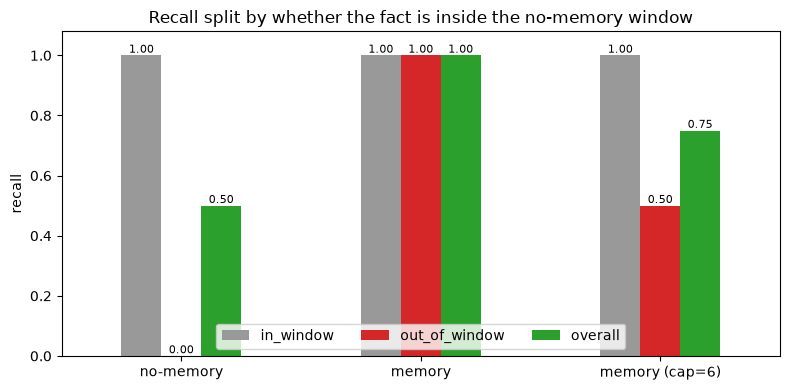

In [ ]:
def split_acc(c):
    flat = lambda ds: [v for d in ds for v in by_dist[c][d]]
    return {
        "overall": float(np.mean(flat(dists))),
        "in_window": float(np.mean(flat([d for d in dists if d <= WINDOW]))),
        "out_of_window": float(np.mean(flat([d for d in dists if d > WINDOW]))),
    }

summary = {c: split_acc(c) for c in CONDITIONS}
summary_df = pd.DataFrame(summary).T[["in_window", "out_of_window", "overall"]]
print(summary_df.round(3).to_string())

ax = summary_df.plot(kind="bar", figsize=(8, 4), rot=0,
                     color={"in_window": "0.6", "out_of_window": "#d62728", "overall": "#2ca02c"})
ax.set_ylabel("recall")
ax.set_title("Recall split by whether the fact is inside the no-memory window")
ax.set_ylim(0, 1.08)
ax.legend(loc="lower center", ncol=3)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8)
plt.tight_layout()
plt.show()

## 5. The harness — a reusable measurement

`make_sessions` plus the three conditions form a small **memory benchmark**. The point of a harness is that every design choice becomes a knob you can turn and re-measure:

| knob | where | what it controls |
|---|---|---|
| write policy | `MemoryWriter(dedup_threshold=…)` | store size vs. lost facts (the trap) |
| capacity | `MemoryWriter(capacity=…)` | the forgetting cliff |
| context budget | `WINDOW` | where the no-memory cliff sits |
| retriever | `DenseRetriever` / hybrid (NB 08) | whether the right fact comes back |
| gate | `gated_rag_answer` (NB 09) | hallucination on out-of-store questions |

Swap any one and re-run for a new curve. That is what the harness buys: it turns "is memory working?" into a number. We save the run so later changes are diffable.

In [ ]:
results = {
    "device": model.device,
    "config": {"n_sessions": len(SESSIONS), "n_facts": len(SESSIONS[0].facts),
               "window_turns": WINDOW, "capacity_facts": CAPACITY},
    "recall_by_distance": {c: {int(d): round(float(np.mean(by_dist[c][d])), 3) for d in dists}
                           for c in CONDITIONS},
    "summary": {c: {k: round(v, 3) for k, v in summary[c].items()} for c in CONDITIONS},
    "dedup_trap": {
        "cosine": {"min": round(float(off.min()), 3), "mean": round(float(off.mean()), 3),
                   "max": round(float(off.max()), 3)},
        "sweep": [{"threshold": r["threshold"], "stored": int(r["stored"]),
                   "recall_at_1": int(r["recall@1"])} for r in rows],
    },
}
path = config.RESULTS_DIR / "10_memory_evaluation_harness.json"
path.write_text(json.dumps(results, indent=2))
print(json.dumps(results["summary"], indent=2))
print(f"\nsaved -> {path.relative_to(config.REPO_ROOT)}")

{
  "no-memory": {
    "overall": 0.5,
    "in_window": 1.0,
    "out_of_window": 0.0
  },
  "memory": {
    "overall": 1.0,
    "in_window": 1.0,
    "out_of_window": 1.0
  },
  "memory (cap=6)": {
    "overall": 0.75,
    "in_window": 1.0,
    "out_of_window": 0.5
  }
}

saved -> docs/LLM/results/10_memory_evaluation_harness.json


## 6. What this means — and the research frontier

The memory arc, in three numbers from this lab's 0.5B model:

- **Retrieval is strong** on distinct facts (NB 08) — a good embedder finds the right note.
- **A relevance gate beats hallucination** (NB 09): unanswerable-question hallucination fell 0.875 → 0.125.
- **Memory beats the context window end-to-end** (here): out-of-window recall rose 0.0 → 1.0.

Put together, a small model *plus* a memory harness behaves like a far more capable long-horizon agent — **provided the write/forget/gate choices are made deliberately.** The open problems are now sharp:

- **Salience — what to write.** write-all stores chit-chat; a real agent must decide which turns are durable facts. That is a `remember` *decision*, the write-side twin of NB 09's gate.
- **Consolidation without losing IDs.** Summarize a cluster of incidents into one note *while keeping every code* — the dedup trap proves naive merging won't do.
- **Calibrated abstention.** A yes/no gate is crude; a confidence with a tunable threshold trades grounding for honesty along a curve.
- **Continual / online memory.** Here the store is built once per session; a real agent reads *and* writes in the same loop, over days, with recency and decay.
- **Long-context vs retrieval.** A bigger window moves the cliff right but never removes it cheaply — when is retrieval the better spend? (Straight back to NB 05.)

That is the bridge from *a model that answers prompts* to *an agent that remembers* — the next phase of the lab.